In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
COLORS = ["#5b9bd5", "#e07b7b"]   # Blue=Benign, Red=Malignant

In [2]:
df=pd.read_csv(r"C:\Breast_Cancer_Prediction\data/dataset.csv",encoding='latin1')
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.drop(columns=['Unnamed: 32'],inplace=True) 
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})
df.tail(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
559,925291,0,11.51,23.93,74.52,403.5,0.09261,0.10210,0.11120,0.04105,...,12.480,37.16,82.28,474.2,0.12980,0.25170,0.3630,0.09653,0.2112,0.08732
560,925292,0,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,...,15.300,33.17,100.20,706.7,0.12410,0.22640,0.1326,0.10480,0.2250,0.08321
561,925311,0,11.20,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.00000,...,11.920,38.30,75.19,439.6,0.09267,0.05494,0.0000,0.00000,0.1566,0.05905
562,925622,1,15.22,30.62,103.40,716.9,0.10480,0.20870,0.25500,0.09429,...,17.520,42.79,128.70,915.0,0.14170,0.79170,1.1700,0.23560,0.4089,0.14090
563,926125,1,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.14740,...,24.290,29.41,179.10,1819.0,0.14070,0.41860,0.6599,0.25420,0.2929,0.09873
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.22160,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.16280,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.14180,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.26500,0.4087,0.12400
568,92751,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.00000,0.2871,0.07039


In [5]:
d=['diagnosis','id']

In [6]:
x=df.drop(columns=d)
x

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [7]:
y=df['diagnosis']
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

## 📊 Data Visualization — Breast Cancer KNN Analysis

### 1️⃣ Diagnosis Distribution — Benign vs Malignant

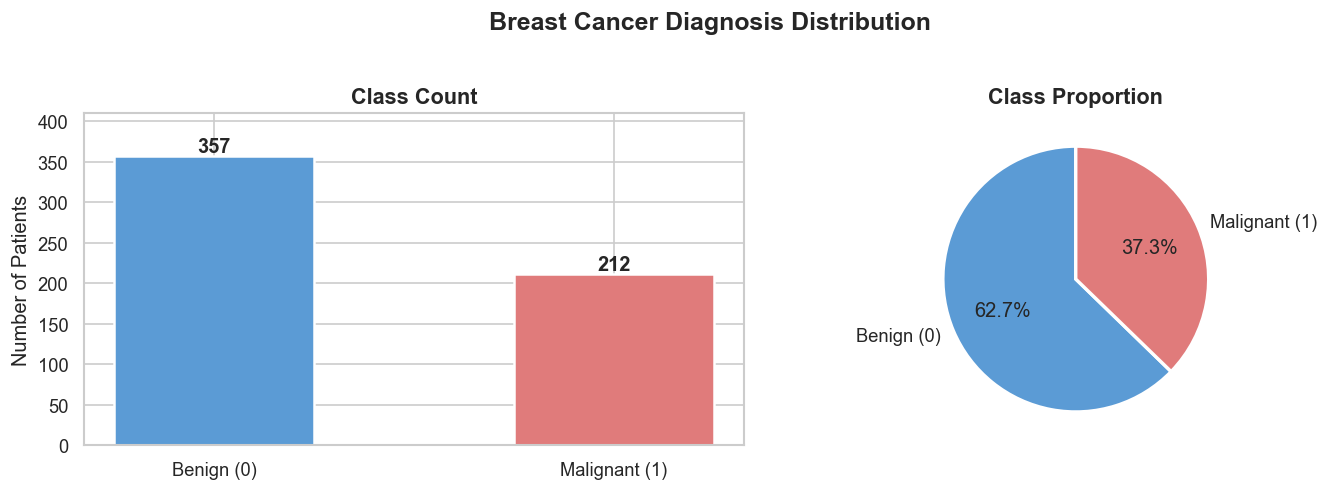

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df["diagnosis"].value_counts()
labels = ["Benign (0)", "Malignant (1)"]

# Bar chart
bars = axes[0].bar(labels, counts.values, color=COLORS, edgecolor="white", linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5, str(val),
                 ha="center", fontweight="bold", fontsize=12)
axes[0].set_title("Class Count", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Patients")
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct="%1.1f%%",
            colors=COLORS, startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Class Proportion", fontsize=13, fontweight="bold")

plt.suptitle("Breast Cancer Diagnosis Distribution", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 2️⃣ Correlation Heatmap


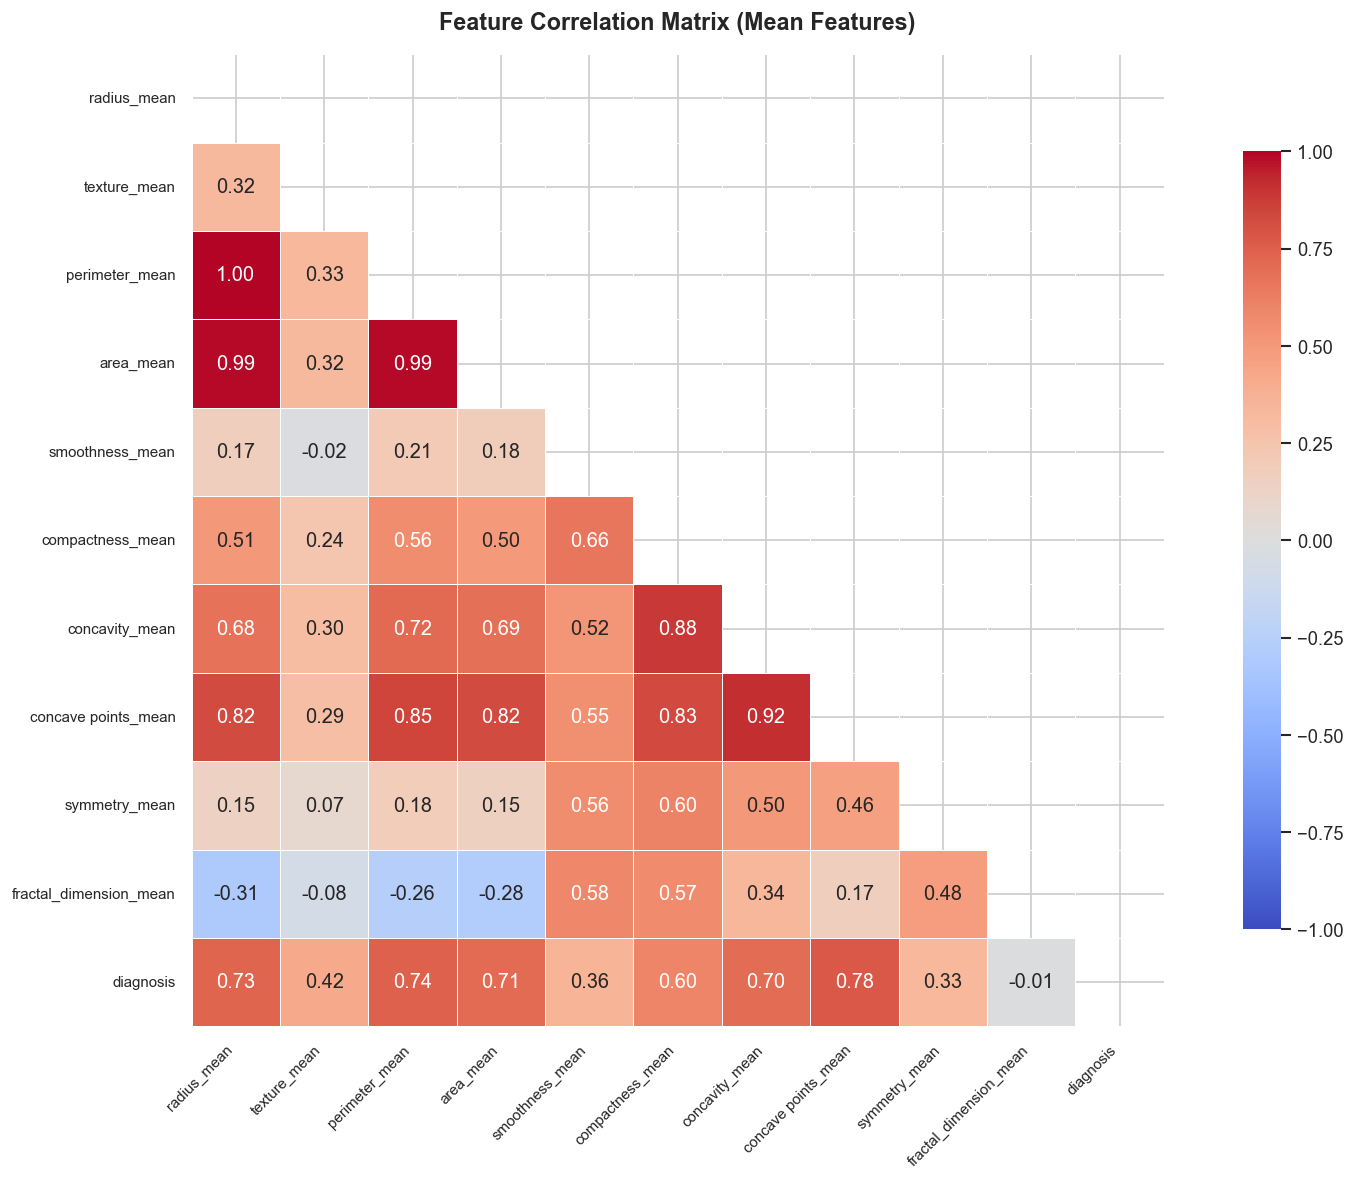

In [9]:
mean_cols = [c for c in df.columns if "_mean" in c] + ["diagnosis"]
corr = df[mean_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix (Mean Features)", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### 3️⃣ Feature Distributions — Benign vs Malignant

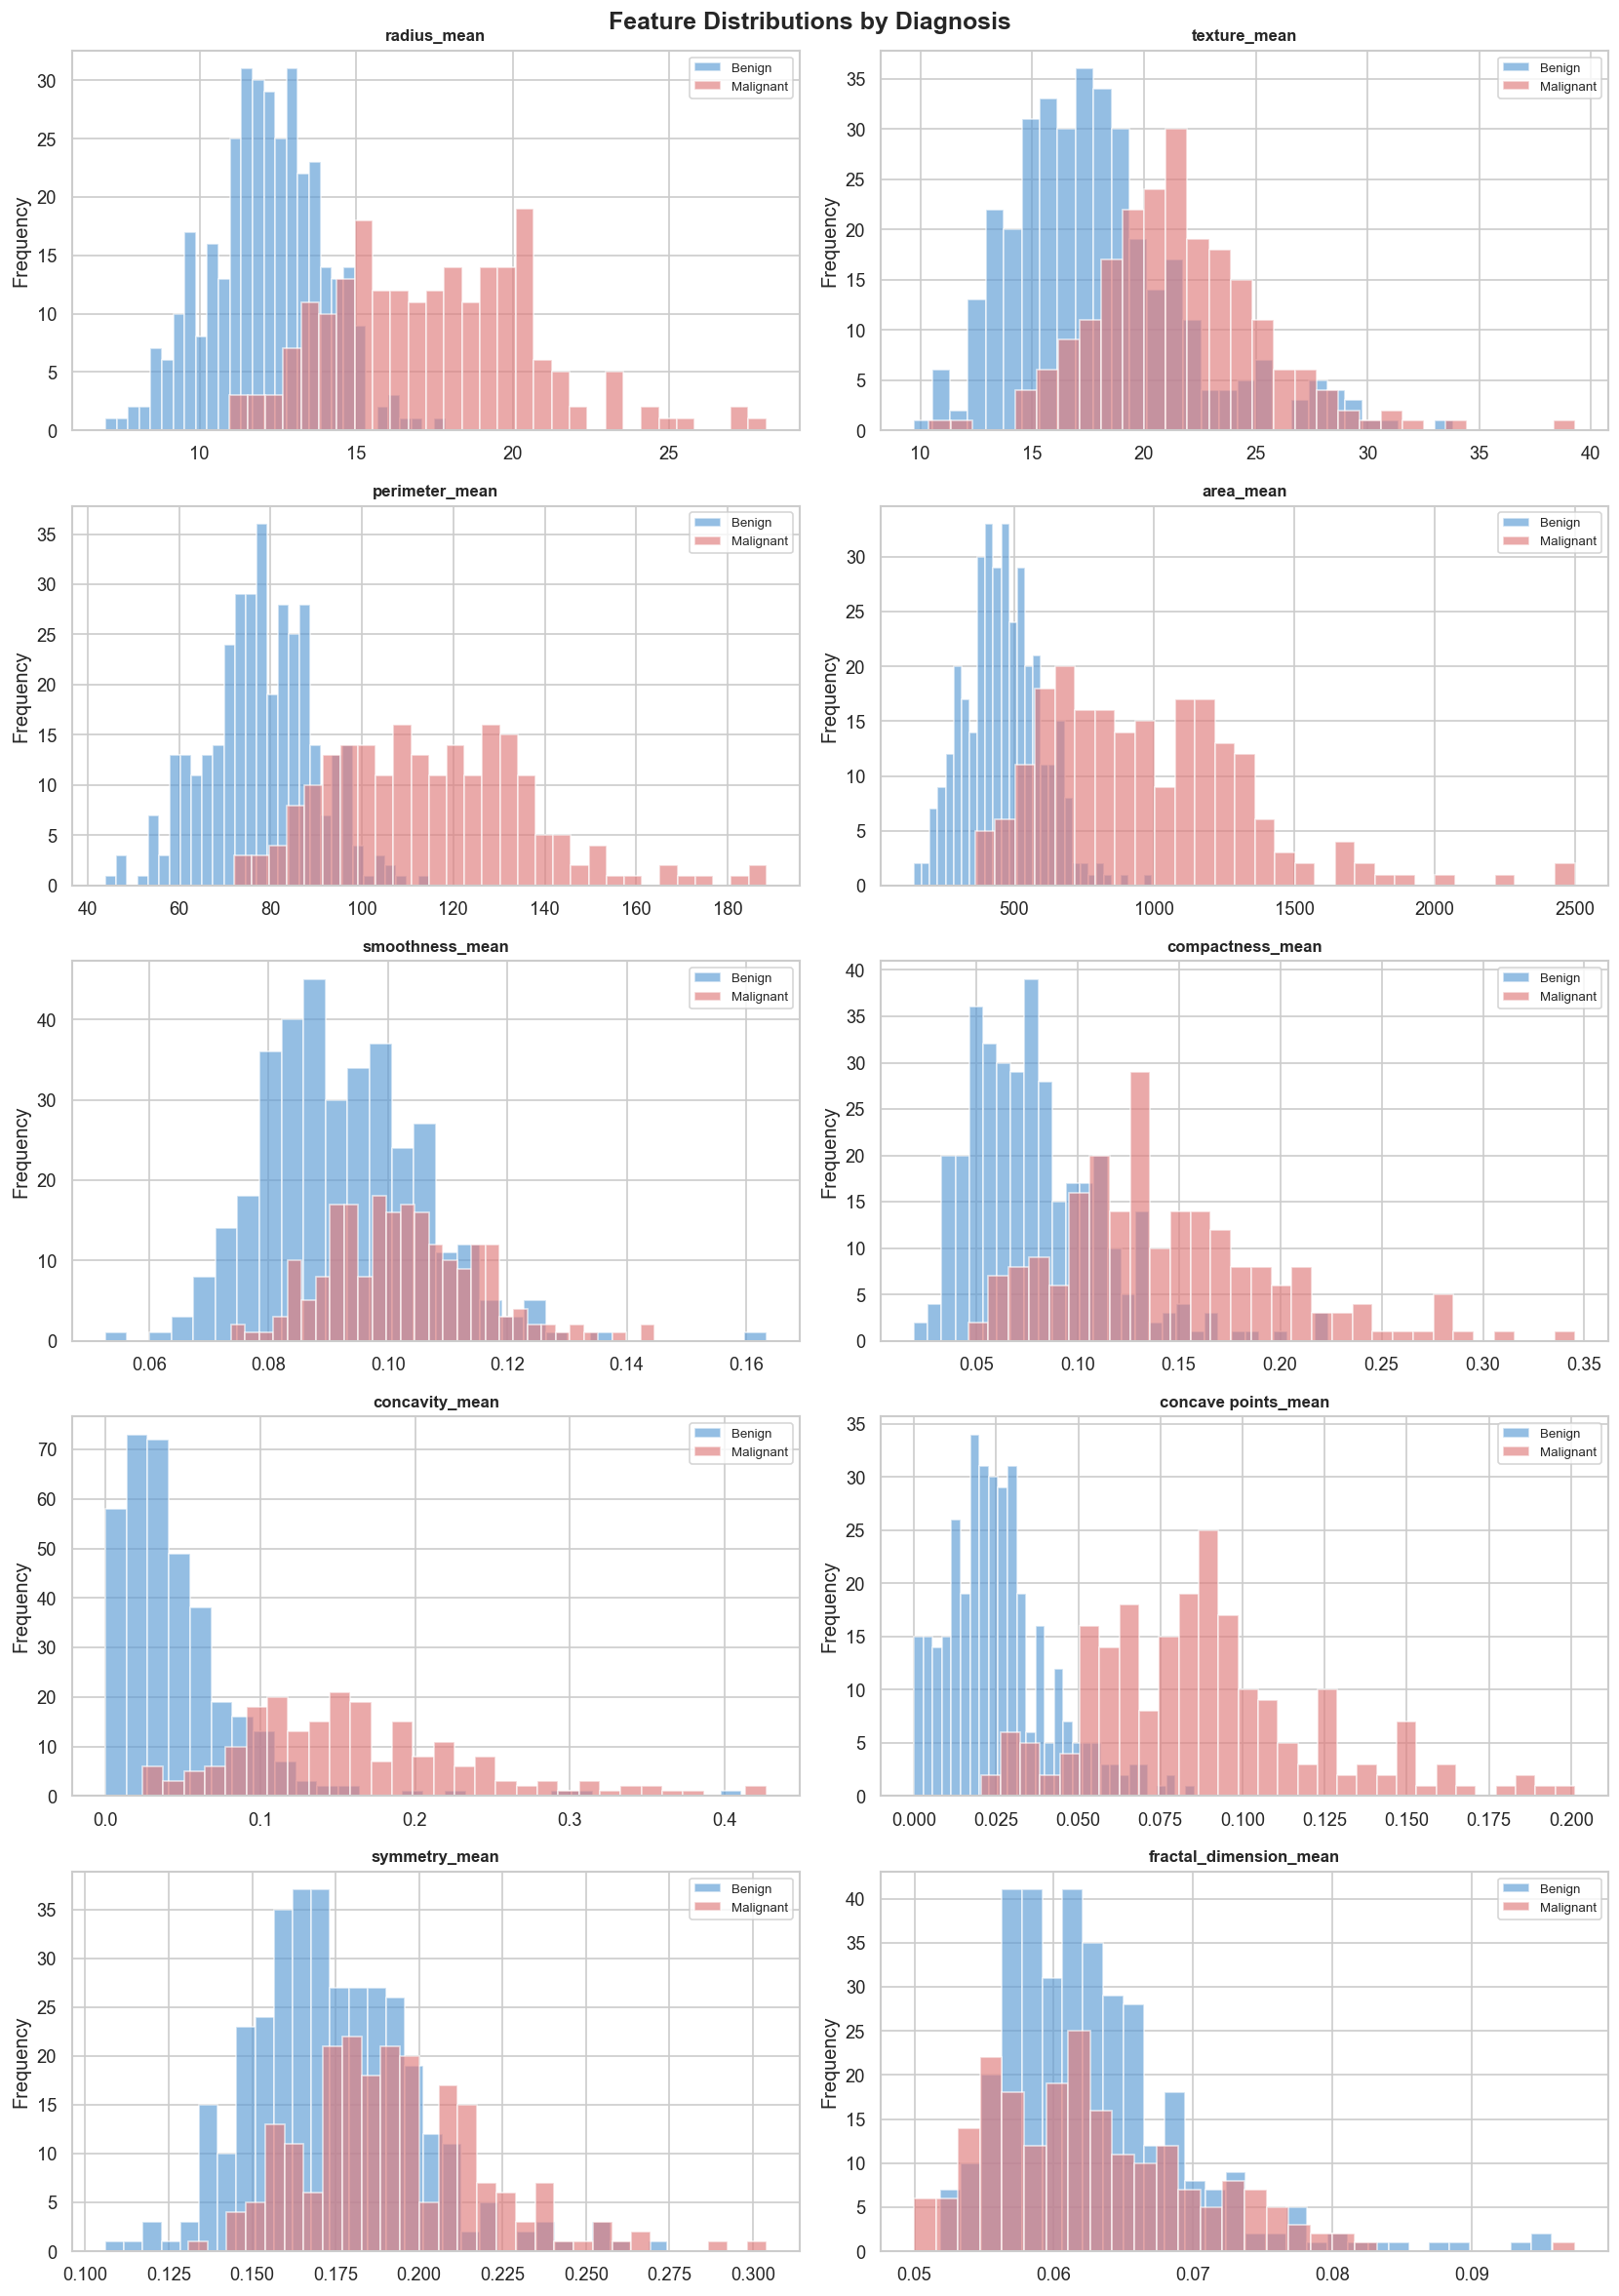

In [10]:
mean_features = [c for c in df.columns if "_mean" in c]
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    axes[i].hist(df[df["diagnosis"]==0][col], bins=30,
                 alpha=0.65, color=COLORS[0], label="Benign", edgecolor="white")
    axes[i].hist(df[df["diagnosis"]==1][col], bins=30,
                 alpha=0.65, color=COLORS[1], label="Malignant", edgecolor="white")
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=8)

plt.suptitle("Feature Distributions by Diagnosis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

4️⃣ Box Plots — Feature Spread by Diagnosis

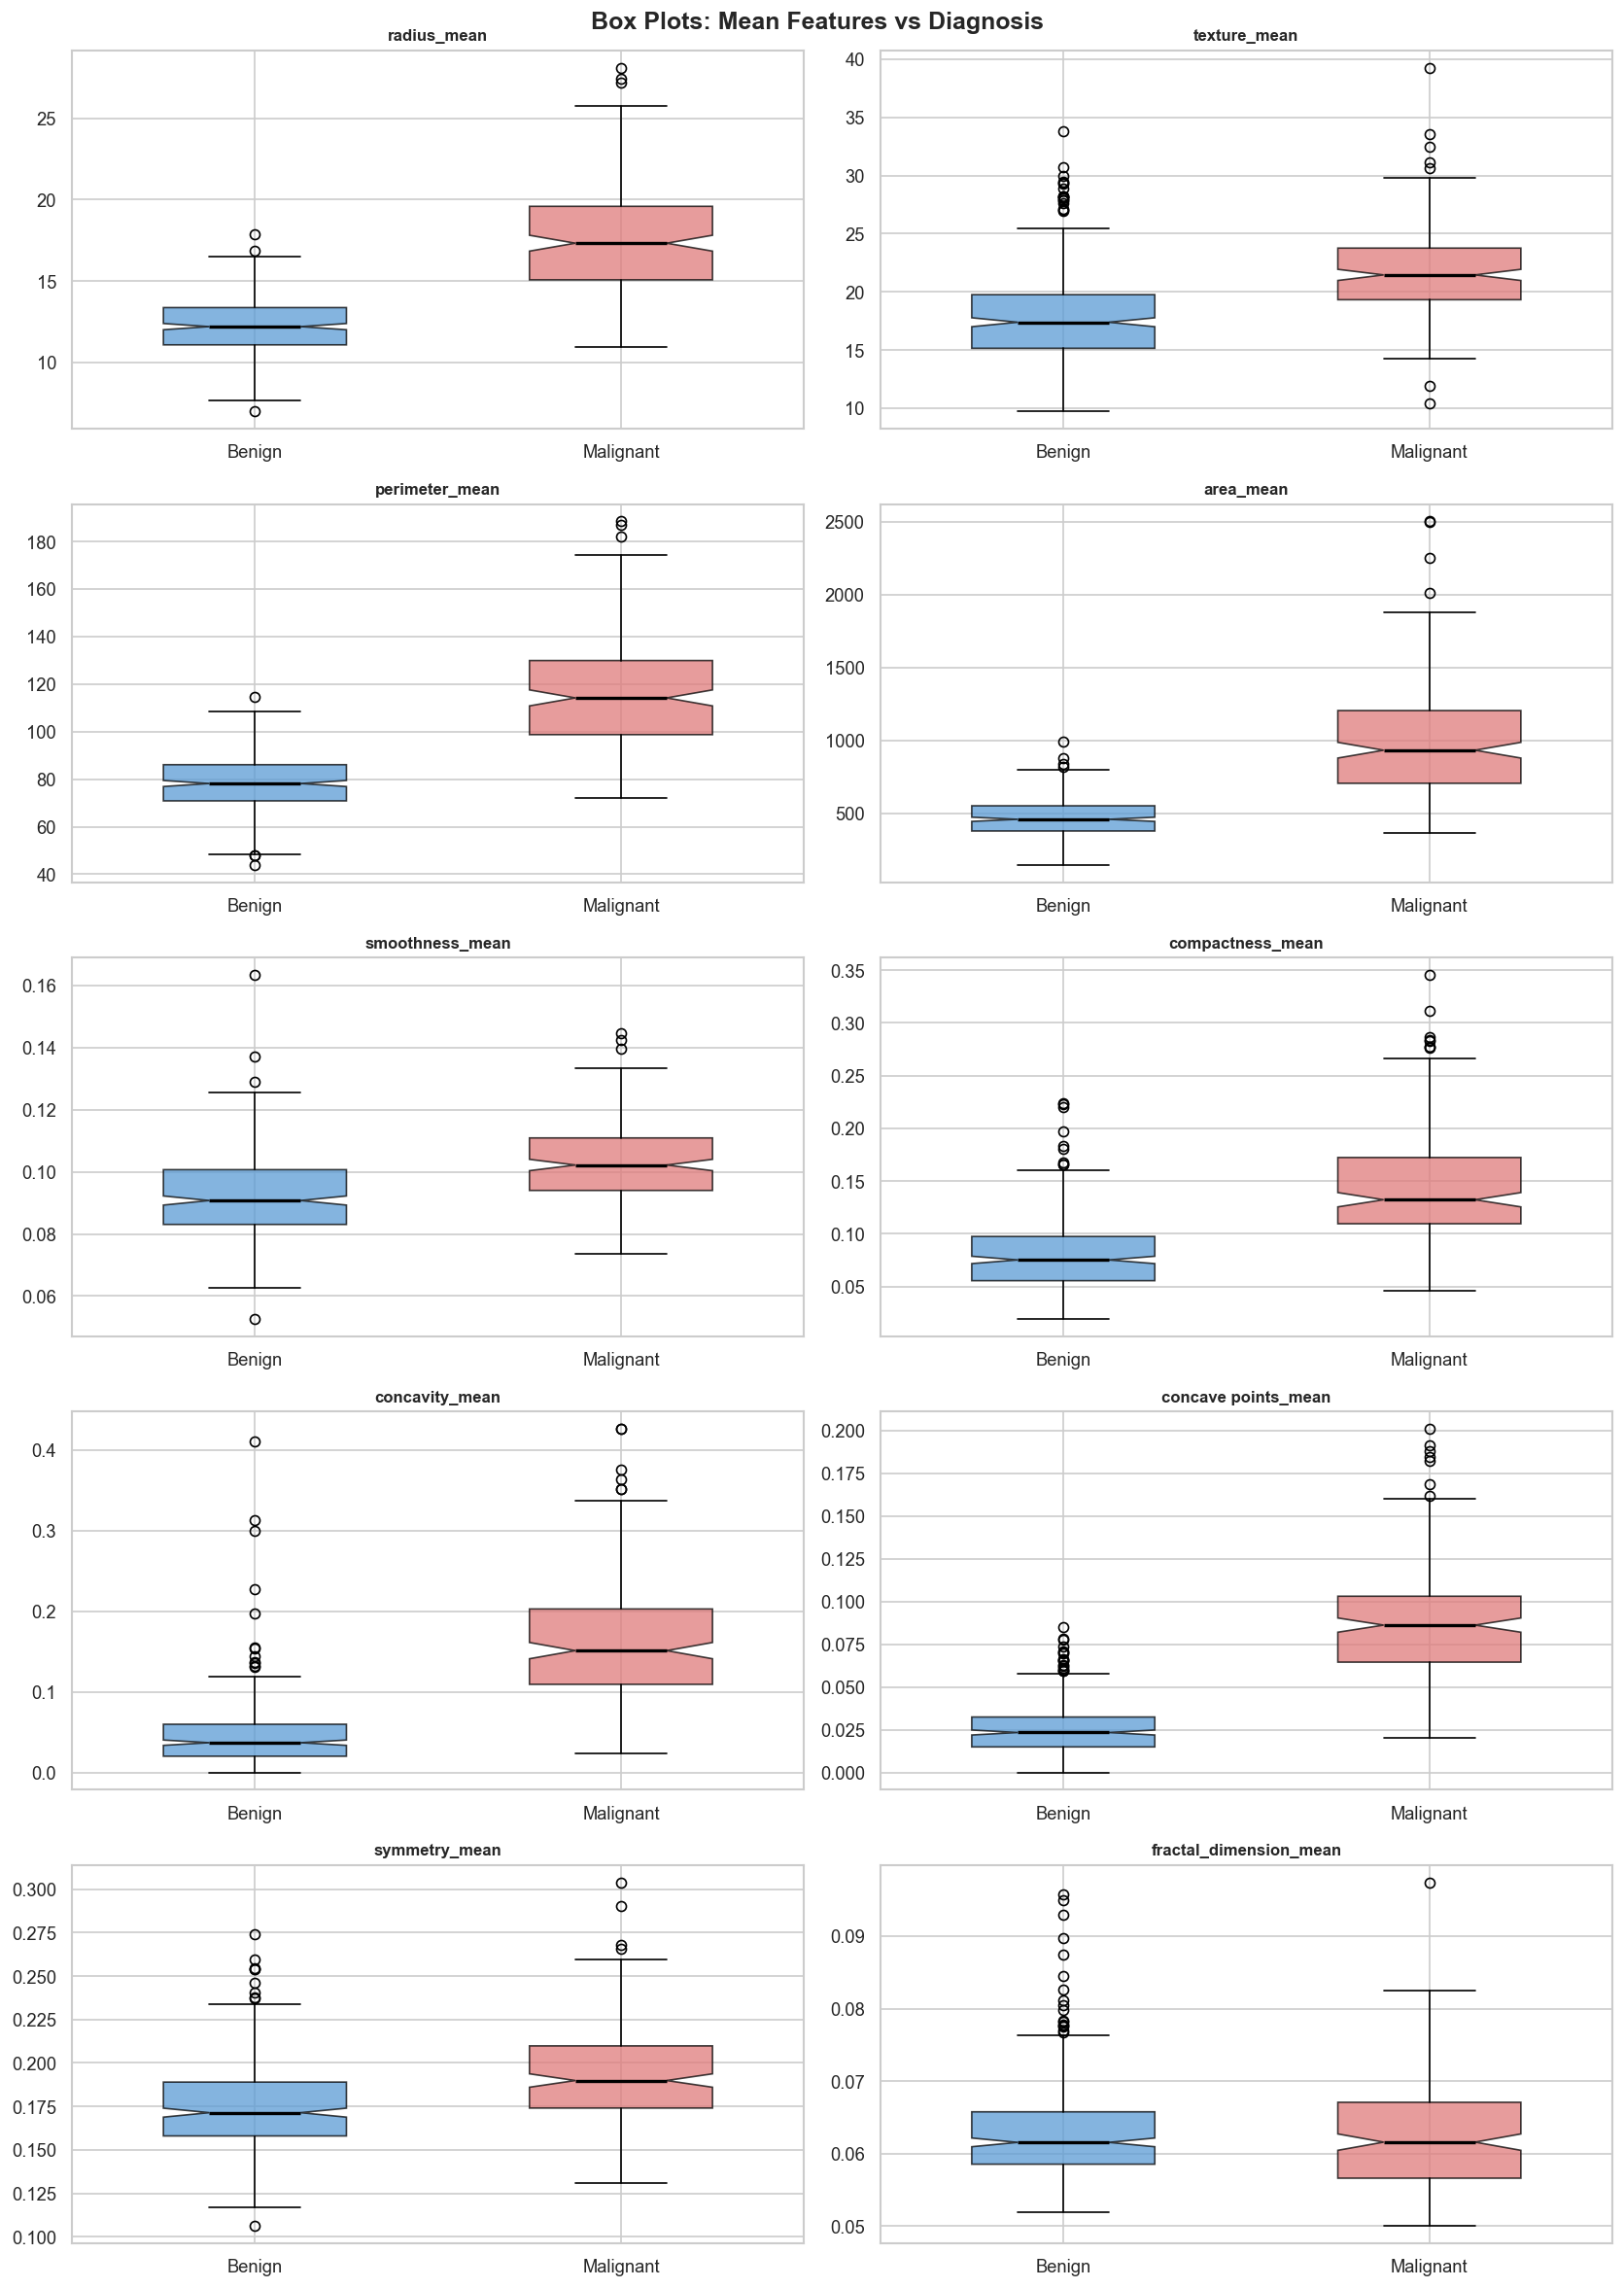

In [11]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    data_b = df[df["diagnosis"]==0][col]
    data_m = df[df["diagnosis"]==1][col]
    bp = axes[i].boxplot([data_b, data_m],
                         labels=["Benign", "Malignant"],
                         patch_artist=True, notch=True, widths=0.5,
                         medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor(COLORS[0])
    bp["boxes"][1].set_facecolor(COLORS[1])
    for patch in bp["boxes"]:
        patch.set_alpha(0.75)
    axes[i].set_title(col, fontsize=10, fontweight="bold")

plt.suptitle("Box Plots: Mean Features vs Diagnosis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=11,test_size=0.2)

In [13]:
scaler=MinMaxScaler(feature_range=(0,1)).set_output(transform='pandas')

In [14]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [15]:
knn=KNeighborsClassifier(n_neighbors=21)

In [16]:
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",21
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [17]:
y_pred=knn.predict(x_test)
y_pred

array([1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 1], dtype=int64)

In [18]:
print("Predicted Score Is:",knn.score(x_test,y_test)*100,"%")

Predicted Score Is: 97.36842105263158 %


In [19]:
print(confusion_matrix(y_test,y_pred))

[[76  0]
 [ 3 35]]


### 5️⃣ KNN Accuracy vs Number of Neighbours (K)

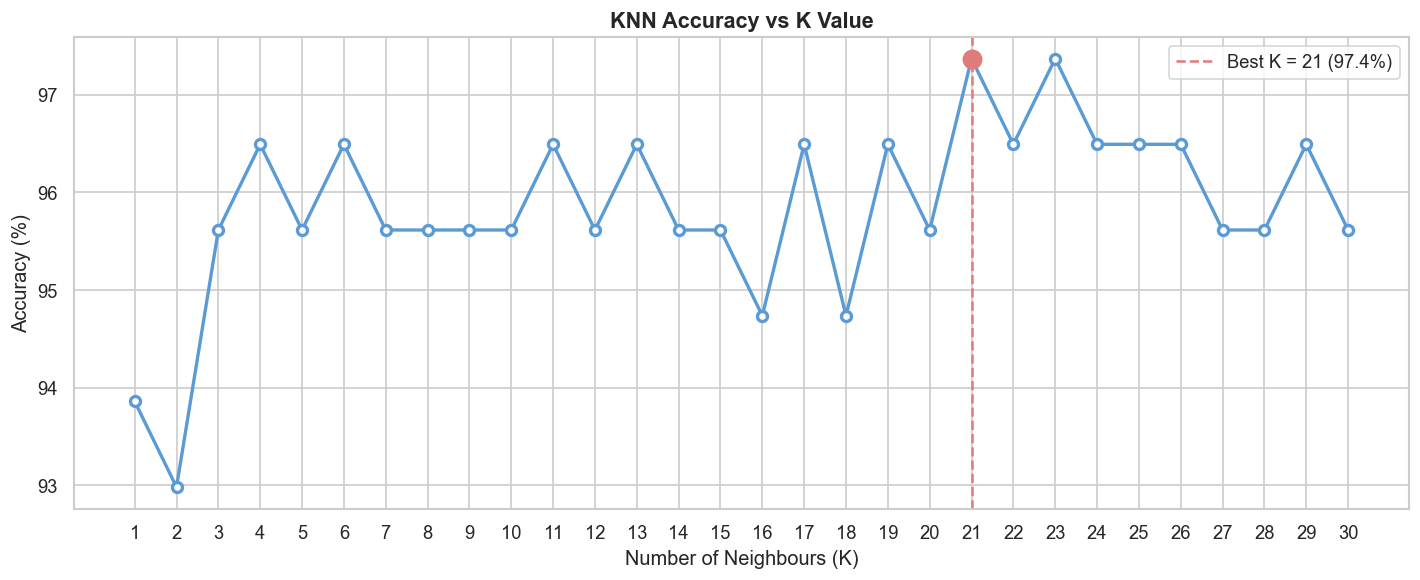

Best K = 21 with accuracy = 97.37%


In [20]:
k_range = range(1, 31)
scores = []
for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(x_train, y_train)
    scores.append(knn_k.score(x_test, y_test) * 100)

best_k = k_range[scores.index(max(scores))]
best_score = max(scores)

plt.figure(figsize=(12, 5))
plt.plot(list(k_range), scores, marker="o", color="#5b9bd5",
         linewidth=2, markersize=6, markerfacecolor="white", markeredgewidth=2)
plt.axvline(best_k, color="#e07b7b", linestyle="--", linewidth=1.5,
            label=f"Best K = {best_k} ({best_score:.1f}%)")
plt.scatter([best_k], [best_score], color="#e07b7b", s=120, zorder=5)
plt.xlabel("Number of Neighbours (K)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("KNN Accuracy vs K Value", fontsize=13, fontweight="bold")
plt.xticks(list(k_range))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
print(f"Best K = {best_k} with accuracy = {best_score:.2f}%")

### 6️⃣ Confusion Matrix Heatmap

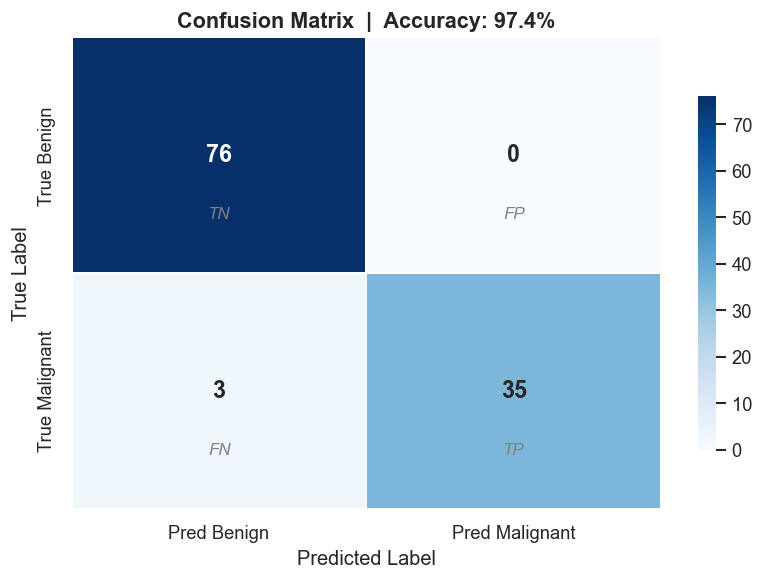

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Benign", "Pred Malignant"],
            yticklabels=["True Benign", "True Malignant"],
            linewidths=1, linecolor="white",
            cbar_kws={"shrink": 0.75},
            annot_kws={"size": 14, "weight": "bold"})

cell_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.75, cell_labels[i][j],
                 ha="center", va="center",
                 fontsize=10, color="gray", style="italic")

acc = knn.score(x_test, y_test) * 100
plt.title(f"Confusion Matrix  |  Accuracy: {acc:.1f}%", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### 7️⃣ Scatter Plot — Radius Mean vs Texture Mean by Diagnosis

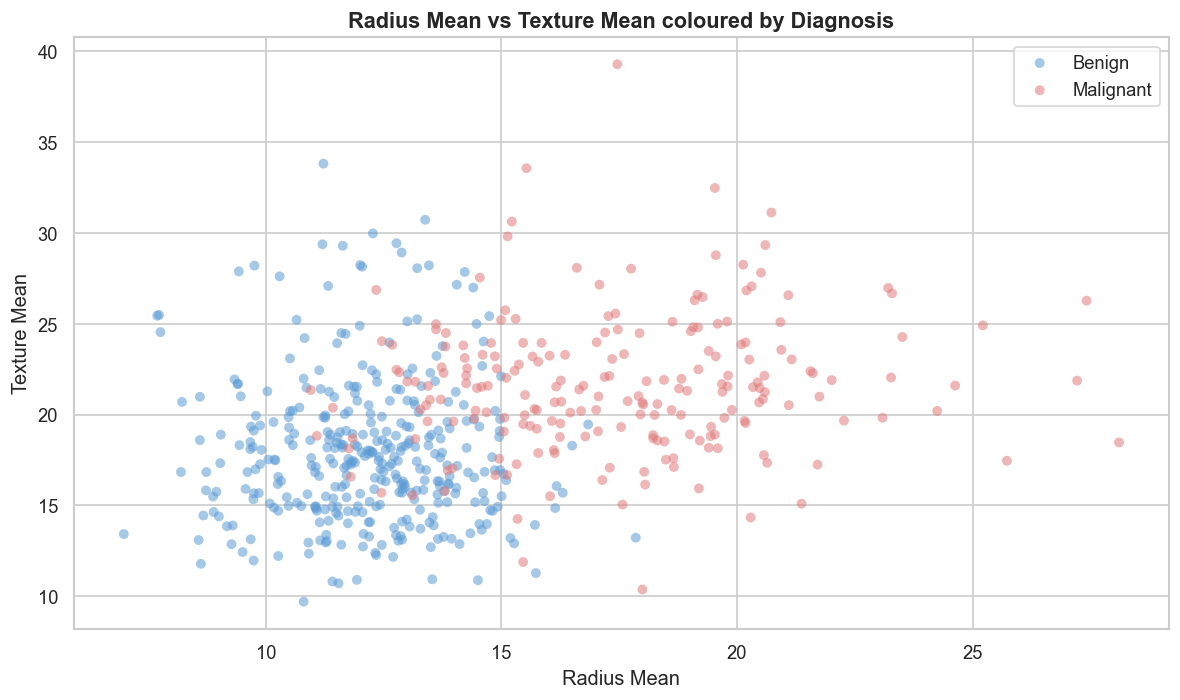

In [22]:
plt.figure(figsize=(10, 6))
for label, name, color in [(0, "Benign", COLORS[0]), (1, "Malignant", COLORS[1])]:
    grp = df[df["diagnosis"] == label]
    plt.scatter(grp["radius_mean"], grp["texture_mean"],
                c=color, label=name, alpha=0.55, s=35, edgecolors="none")

plt.xlabel("Radius Mean", fontsize=12)
plt.ylabel("Texture Mean", fontsize=12)
plt.title("Radius Mean vs Texture Mean coloured by Diagnosis",
          fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 8️⃣ Top Features Most Correlated with Diagnosis

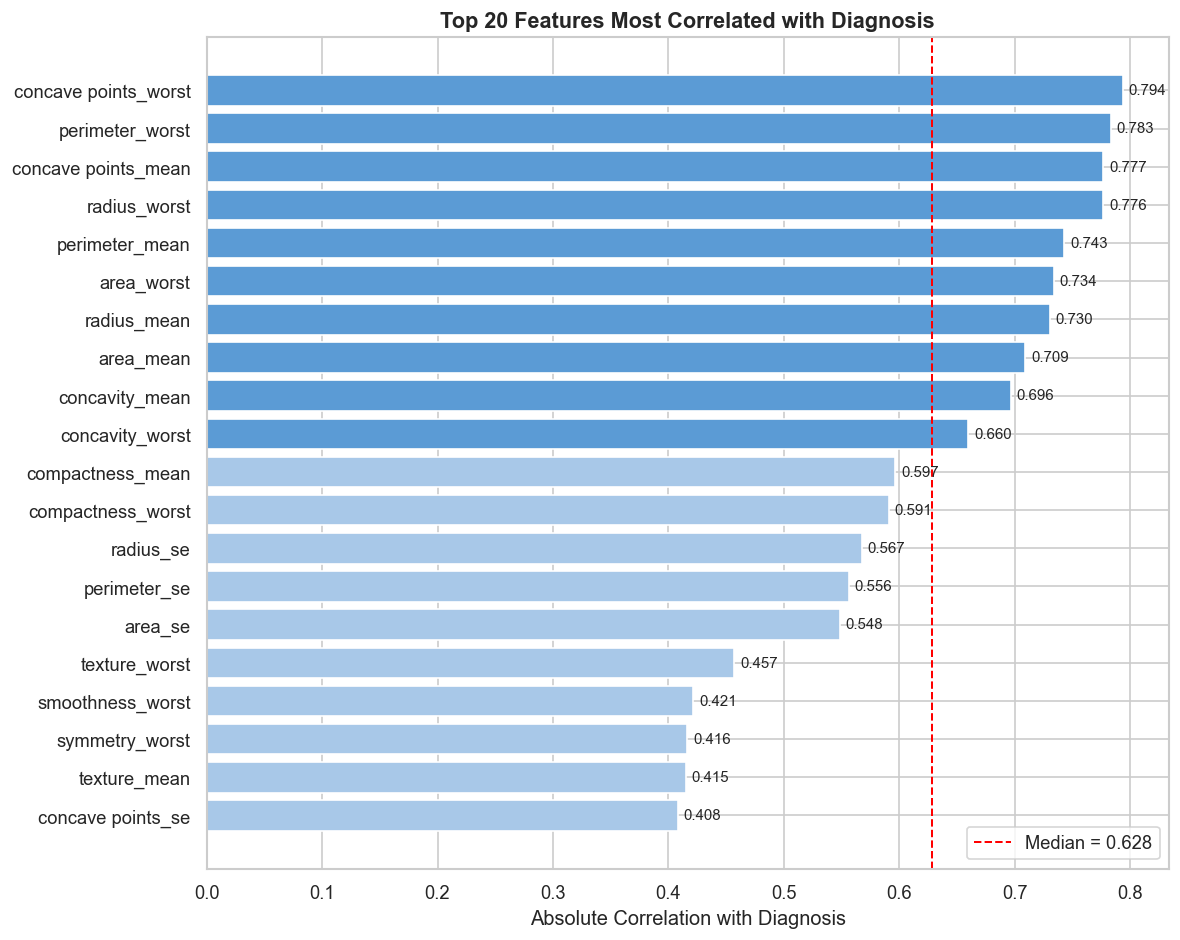

In [23]:
corr_with_target = df.corr()["diagnosis"].drop("diagnosis").abs().sort_values(ascending=True)
top_feats = corr_with_target[-20:]  # top 20

colors_bar = ["#5b9bd5" if v >= corr_with_target[-20:].median() else "#a8c8e8"
              for v in top_feats]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top_feats.index, top_feats.values, color=colors_bar, edgecolor="white")
for bar, val in zip(bars, top_feats.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

ax.axvline(top_feats.median(), color="red", linestyle="--", linewidth=1.2,
           label=f"Median = {top_feats.median():.3f}")
ax.set_xlabel("Absolute Correlation with Diagnosis", fontsize=12)
ax.set_title("Top 20 Features Most Correlated with Diagnosis",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

###